# **How do we plot coin-flip probabilities with Matplotlib?**

In [3]:
#importing matplotlib
import matplotlib.pyplot as plt

In [2]:
from itertools import product
from collections import defaultdict

def generate_coin_sample_space(num_flips=10):
  weighted_sample_space = defaultdict(int)
  for coin_flips in product(['Heads', 'Tails'], repeat=num_flips):
    heads_count = len([outcome for outcome in coin_flips if outcome == 'Heads'])
    weighted_sample_space[heads_count] += 1
  return weighted_sample_space
weighted_sample_space = generate_coin_sample_space()

In [4]:
weighted_sample_space

defaultdict(int,
            {10: 1,
             9: 10,
             8: 45,
             7: 120,
             6: 210,
             5: 252,
             4: 210,
             3: 120,
             2: 45,
             1: 10,
             0: 1})

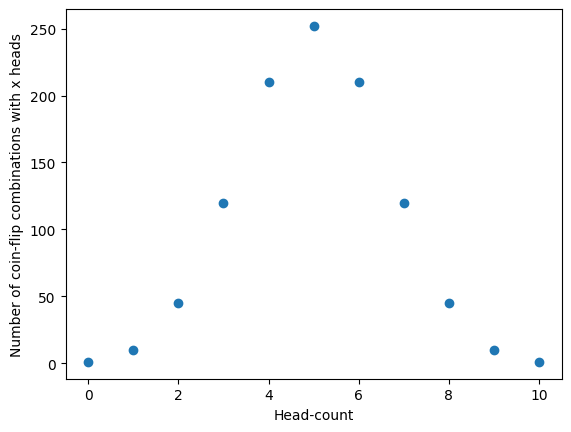

In [5]:
#plotting the coin-flip weighted sample space
x_10_flips = list(weighted_sample_space.keys())
y_10_flips = [weighted_sample_space[key] for key in x_10_flips]
plt.scatter(x_10_flips, y_10_flips)
plt.xlabel('Head-count')
plt.ylabel('Number of coin-flip combinations with x heads')
plt.show()

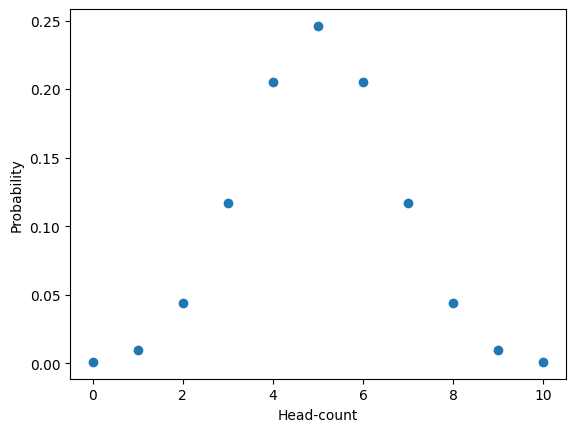

In [6]:
#plotting the coin-flip probabilities
sample_space_size = sum(weighted_sample_space.values())
prob_x_10_flips = [value / sample_space_size for value in y_10_flips]
plt.scatter(x_10_flips, prob_x_10_flips)
plt.xlabel('Head-count')
plt.ylabel('Probability')
plt.show()

In [7]:
#confirming that all probabilities sum to 1
assert sum(prob_x_10_flips) == 1.0

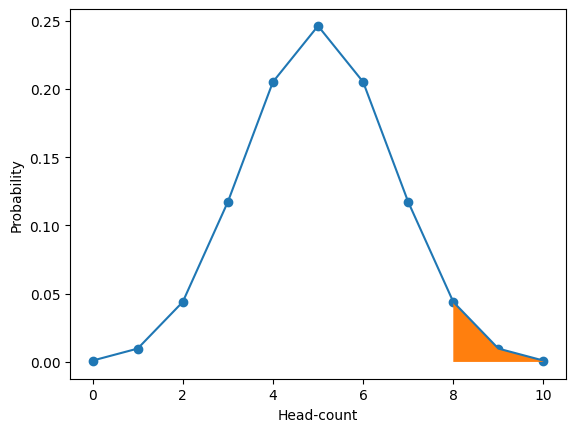

In [8]:
#shading the intercal under a probability curve
def is_in_interval(number, minimum, maximum):
  return minimum <= number <= maximum

plt.plot(x_10_flips, prob_x_10_flips)
plt.scatter(x_10_flips, prob_x_10_flips)
where = [is_in_interval(value, 8, 10) for value in x_10_flips]
plt.fill_between(x_10_flips, prob_x_10_flips, where=where)
plt.xlabel('Head-count')
plt.ylabel('Probability')
plt.show()

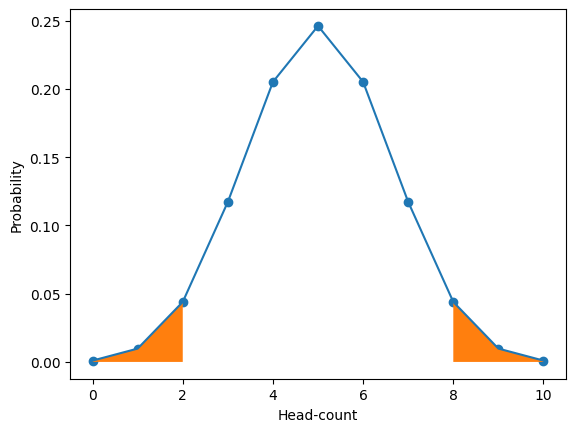

In [9]:
# Shading the interval under the extremes of a probability curve
plt.plot(x_10_flips, prob_x_10_flips)
plt.scatter(x_10_flips, prob_x_10_flips)
where = [not is_in_interval(value, 3, 7) for value in x_10_flips]
plt.fill_between(x_10_flips, prob_x_10_flips, where=where)
plt.xlabel('Head-count')
plt.ylabel('Probability')
plt.show()

We take weighted sample space from chapter 1 and then:
1) Place the number of heads on the x-axis(0 through N)
2) Place the probability of that number of heads on the y-axis (combination count/total combinations)
3) Use plt.scatter and plt.plot to visualize